In [2]:
# Libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.lines import Line2D
from numpy import linalg as LA
from scipy.optimize import fsolve, brentq

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Параметры сети: <k> = 3.92 ; ζ = 10.04 ; kmax = 67 ; kmin = 2 ; n = 2.91


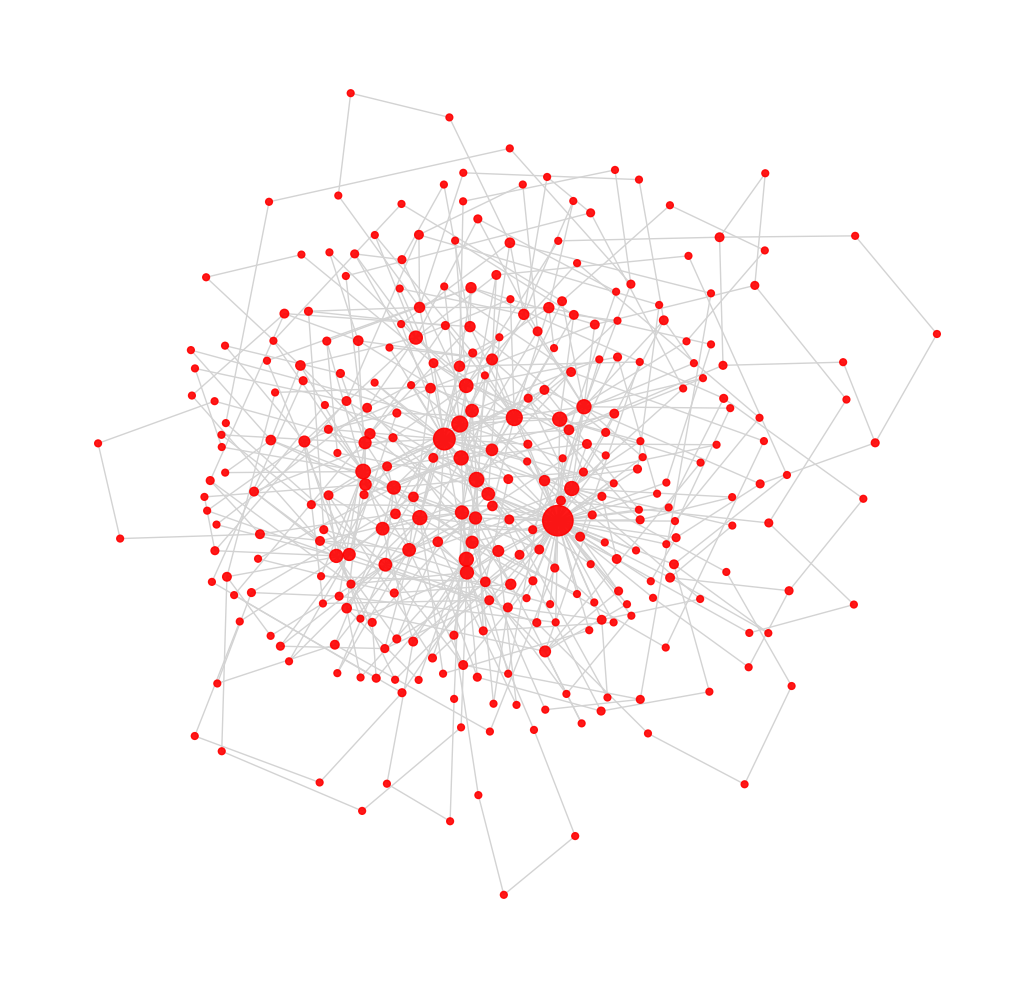

In [3]:
edge_list_file = "/content/drive/MyDrive/Graphs/N300_y2.9.edgelist"

G = nx.read_edgelist(edge_list_file)

# Сохраняем сеть для Gephi
nx.write_gexf(G, "N300_y2.9.gexf")

# Основные параметры сети
nodes = list(G.nodes())
N = len(nodes)

# Матрица смежности
A = nx.adjacency_matrix(G, nodelist=nodes)
A_np = nx.to_numpy_array(G, nodelist=nodes)

# Степени узлов
k_array = np.array([G.degree(v) for v in nodes], dtype=float)
k1 = np.mean(k_array)       # <k>
k2 = np.mean(k_array**2)    # <k^2>

# lambda_1 = <k^2>/<k>
zeta = k2 / k1
maxk = int(np.max(k_array))
mink = int(np.min(k_array))
eg = LA.eigvals(A_np)

def degree_exponent_equation(x):
    return mink * (x - 1) / (2 - x) * (N ** ((2 - x) / (x - 1)) - 1) - k1
root = fsolve(degree_exponent_equation, x0=2.1)
eta_est = round(root[0], 2)
z = mink * ((2 - eta_est) / (3 - eta_est)) * ((N ** ((3 - eta_est) / (eta_est - 1)) - 1) / (N ** ((2 - eta_est) / (eta_est - 1)) - 1))
print("Параметры сети:", "<k> =", round(k1, 2), "; ζ =", round(zeta, 2), "; kmax =", maxk, "; kmin =", mink, "; n =", eta_est)

def draw_graph(G, layout="kamada", node_color="black", edge_color="lightgray", scale=7, figsize=(10.45, 10)):
    layouts = {
        "spring": nx.spring_layout,
        "circular": nx.circular_layout,
        "kamada": nx.kamada_kawai_layout,
        "shell": nx.shell_layout}

    pos = layouts.get(layout, nx.kamada_kawai_layout)(G)
    degrees = dict(G.degree())
    node_sizes = [scale * degrees[n] + 10 for n in G.nodes()]
    plt.figure(figsize=figsize)
    nx.draw_networkx_edges(G, pos, edge_color=edge_color, alpha=1, width=1)
    nx.draw_networkx_nodes(G, pos,  node_color=node_color, node_size=node_sizes, alpha=0.9)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_graph(G, layout="kamada", node_color="red")

In [4]:
def choose_ai_nodes(strategy, nodes, deg, N0, seed=42):
    rng = np.random.default_rng(seed)
    N_local = len(nodes)
    if strategy == "hub-first":
        idx = np.argsort(-deg)[:N0]
    elif strategy == "random":
        idx = rng.choice(np.arange(N_local), size=N0, replace=False)
    elif strategy == "periphery-first":
        idx = np.argsort(deg)[:N0]
    else:
        raise ValueError("Условие: hub-first, random, periphery-first")
    ai_nodes = [nodes[i] for i in idx]
    return ai_nodes

def ai_nodes_to_eps(ai_nodes, nodes):
    ai_set = set(ai_nodes)
    eps = np.array([1 if n in ai_set else 0 for n in nodes], dtype=float)
    return eps

def compute_overlaps(eps, u):
    S_B = np.sum(eps * u**2)
    c1 = np.sqrt(S_B * (1.0 - S_B))
    d1 = 1.0 - S_B
    Delta_eps = S_B * d1 - c1**2
    return S_B, c1, d1, Delta_eps

def compute_strategy_results_for_graph(G_tmp, f_adopt=0.45, seed=42):
    nodes_tmp = list(G_tmp.nodes())
    N_tmp = len(nodes_tmp)
    deg_tmp = np.array([G_tmp.degree(v) for v in nodes_tmp], dtype=float)
    N0_tmp = int(round(f_adopt * N_tmp))
    u_tmp = deg_tmp / np.sqrt(np.sum(deg_tmp**2))
    hub_nodes_tmp = choose_ai_nodes("hub-first", nodes_tmp, deg_tmp, N0_tmp)
    random_nodes_tmp = choose_ai_nodes("random", nodes_tmp, deg_tmp, N0_tmp, seed=seed)
    periphery_nodes_tmp = choose_ai_nodes("periphery-first", nodes_tmp, deg_tmp, N0_tmp)
    eps_hub_tmp = ai_nodes_to_eps(hub_nodes_tmp, nodes_tmp)
    eps_random_tmp = ai_nodes_to_eps(random_nodes_tmp, nodes_tmp)
    eps_periphery_tmp = ai_nodes_to_eps(periphery_nodes_tmp, nodes_tmp)
    strategy_eps_tmp = {
        "Hub-first": eps_hub_tmp,
        "Random": eps_random_tmp,
        "Periphery-first": eps_periphery_tmp}
    result_tmp = {}
    for name, eps in strategy_eps_tmp.items():
        S_B, c1, d1, Delta_eps = compute_overlaps(eps, u_tmp)
        result_tmp[name] = {"S_B": S_B, "c1": c1, "d1": d1, "Delta_eps": Delta_eps, "S_B_over_f": S_B / f_adopt}
    return result_tmp

def draw_three_ai_strategies(G, nodes, strategy_eps, layout="kamada", scale=7, figsize=(18, 6)):
    layouts = {
        "spring": nx.spring_layout,
        "circular": nx.circular_layout,
        "kamada": nx.kamada_kawai_layout,
        "shell": nx.shell_layout}

    pos = layouts.get(layout, nx.kamada_kawai_layout)(G)
    degrees = dict(G.degree())
    node_sizes = [scale * degrees[n] + 10 for n in nodes]
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    for ax, (title, eps) in zip(axes, strategy_eps.items()):
        node_colors = [
            "red" if eps[i] == 1 else "lightgray"
            for i in range(len(nodes))]
        nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.15, width=0.6, ax=ax)
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors, node_size=node_sizes, alpha=0.9, linewidths=0.2, edgecolors="black", ax=ax)
        ax.set_title(title, fontsize=13)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def Q_B_uniform(mode):
    if mode == "bright":
        return 1.0
    elif mode == "dark":
        return 0.0
    else:
        raise ValueError("mode должен быть 'bright' или 'dark'")

In [5]:
def L_complex_matrix(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1):
    L = np.array([
        [   -Gamma + (S_B * C + J_I * lam1) * z0
            - 1j * (S_B * M + J_R * lam1) * z0,
            c1 * (C - 1j * M) * z0],
        [   c1 * (C - 1j * M) * z0,
            -Gamma + d1 * (C - 1j * M) * z0]], dtype=complex)
    return L

def Q_B_from_eigenvector(v):
    B = v[0]
    D = v[1]
    denom = np.abs(B)**2 + np.abs(D)**2
    if denom < 1e-14:
        return np.nan
    return np.abs(B)**2 / denom

def Q_B_value_complex(S_B, c1, d1, z0, J_R, J_I, C, M, Gamma, lam1):
    #L = L_complex_matrix(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1)
    #eigvals, eigvecs = np.linalg.eig(L)
    #idx = np.argmin(np.abs(np.real(eigvals)))
    #v = eigvecs[:, idx]
    #return Q_B_from_eigenvector(v)
    L = L_complex_matrix(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1)
    mu, eigvecs = np.linalg.eig(L)
    nu = 1j * mu
    idx = np.argmin(np.abs(np.imag(nu)))
    v = eigvecs[:, idx]
    return Q_B_from_eigenvector(v)

def threshold_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1):
    a = (S_B * C + J_I * lam1) * d1 * C - c1**2 * C**2
    b = Gamma * (S_B * C + J_I * lam1 + d1 * C)
    c = Gamma**2
    if abs(a) < 1e-12:
        if abs(b) < 1e-12:
            return []
        z = c / b
        return [z] if z > 0 else []
    Dscr = b**2 - 4 * a * c
    if Dscr < 0:
        return []
    z1 = (b - np.sqrt(Dscr)) / (2 * a)
    z2 = (b + np.sqrt(Dscr)) / (2 * a)
    roots = sorted([z for z in [z1, z2] if z > 0])
    return roots

def threshold_negative_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1):
    a = (S_B * C + J_I * lam1) * d1 * C - c1**2 * C**2
    b = Gamma * (S_B * C + J_I * lam1 + d1 * C)
    c = Gamma**2
    if abs(a) < 1e-12:
        if abs(b) < 1e-12:
            return []
        z = c / b
        return [z] if z < 0 else []
    Dscr = b**2 - 4 * a * c
    if Dscr < 0:
        return []
    z1 = (b - np.sqrt(Dscr)) / (2 * a)
    z2 = (b + np.sqrt(Dscr)) / (2 * a)
    roots = sorted([z for z in [z1, z2] if z < 0])
    return roots

def Q_B_value_real(S_B, c1, z0, J_I, C, Gamma, lam1):
    if c1 < 1e-12:
        return 1.0
    n = Gamma - (S_B * C + J_I * lam1) * z0
    d = c1 * C * z0
    if abs(d) < 1e-12:
        return 1.0
    return 1.0 / (1.0 + (n / d)**2)

def real_eigs_complex(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1):
    L = L_complex_matrix(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1)
    #eigvals = np.linalg.eigvals(L)
    #return np.sort(np.real(eigvals))
    mu = np.linalg.eigvals(L)
    nu = 1j * mu
    return np.sort(np.imag(nu))

def find_complex_roots_by_scan(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, z_min=0.0, z_max=30.0, n_grid=2000):
    z_grid = np.linspace(z_min, z_max, n_grid)
    vals = np.array([
        real_eigs_complex(S_B, c1, d1, J_R, J_I, z0, C, M, Gamma, lam1)
        for z0 in z_grid])
    roots = []
    for branch in [0, 1]:
        y = vals[:, branch]
        for i in range(len(z_grid) - 1):
            z_left = z_grid[i]
            z_right = z_grid[i + 1]
            y_left = y[i]
            y_right = y[i + 1]
            if np.isnan(y_left) or np.isnan(y_right):
                continue
            if abs(y_left) < 1e-10:
                root = z_left
            elif y_left * y_right < 0:
                root = z_left - y_left * (z_right - z_left) / (y_right - y_left)
            else:
                continue
            if z_min <= root <= z_max:
                roots.append(root)
    roots_unique = []
    for r in sorted(roots):
        if not any(abs(r - rr) < 1e-4 for rr in roots_unique):
            roots_unique.append(r)
    return roots_unique

def get_roots(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, positive=True):
    if abs(J_R) < 1e-14 and abs(M) < 1e-14:
        if positive:
            return threshold_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1)
        else:
            return threshold_negative_roots_real(S_B, c1, d1, J_I, C, Gamma, lam1)
    if positive:
        return find_complex_roots_by_scan(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, z_min=0.0, z_max=30.0, n_grid=2000)
    else:
        return find_complex_roots_by_scan(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, z_min=-30.0, z_max=0.0, n_grid=2000)

def get_Q_B(S_B, c1, d1, z0, J_R, J_I, C, M, Gamma, lam1):
    if np.isnan(z0):
        return np.nan
    if abs(J_R) < 1e-14 and abs(M) < 1e-14:
        return Q_B_value_real(S_B, c1, z0, J_I, C, Gamma, lam1)
    return Q_B_value_complex(S_B, c1, d1, z0, J_R, J_I, C, M, Gamma, lam1)

def extract_two_roots(roots):
    roots = sorted(roots)
    if len(roots) == 0:
        return np.nan, np.nan
    if len(roots) == 1:
        return roots[0], np.nan
    return roots[0], roots[1]

In [6]:
f_adopt = 0.45
N0 = int(round(f_adopt * N))

nodes = list(G.nodes())
deg = np.array([G.degree(v) for v in nodes], dtype=float)

Gcoop = 3.0
Gamma = 2.0
C = Gamma * Gcoop

# Комплексные параметры
J_R = 0.0     # J_R = J'
M = 0.0       # фазовый вклад AI

# Диапазон J_I = J''
Jpp_values = np.linspace(-5, 5, 1000)

lam1 = zeta

u = deg / np.sqrt(np.sum(deg**2))

print("N =", N, "; N0 =", N0, "; f =", N0 / N)
print("Gcoop =", Gcoop, "; Gamma =", Gamma, "; C =", C)
print("J_R =", J_R, "; M =", M)
print("λ1 = ζ =", round(lam1, 4))
print("Проверка нормировки sum(u_i^2) =", round(np.sum(u**2), 6))

hub_nodes = choose_ai_nodes("hub-first", nodes, deg, N0)
random_nodes = choose_ai_nodes("random", nodes, deg, N0, seed=42)
periphery_nodes = choose_ai_nodes("periphery-first", nodes, deg, N0)

eps_hub = ai_nodes_to_eps(hub_nodes, nodes)
eps_random = ai_nodes_to_eps(random_nodes, nodes)
eps_periphery = ai_nodes_to_eps(periphery_nodes, nodes)

strategy_eps = {
    "Hub-first": eps_hub,
    "Random": eps_random,
    "Periphery-first": eps_periphery}

results = {}
print("\nИтоговые коэффициенты:")
print("strategy          S_B      S_B/f     c1       d1       Delta_eps")

for name, eps in strategy_eps.items():
    S_B, c1, d1, Delta_eps = compute_overlaps(eps, u)
    results[name] = {"eps": eps, "S_B": S_B, "c1": c1, "d1": d1, "Delta_eps": Delta_eps}
    print(f"{name:<16} " f"{S_B:7.4f} " f"{S_B/f_adopt:7.4f} " f"{c1:7.4f} " f"{d1:7.4f}  "  f"{Delta_eps:10.2e}")

N = 300 ; N0 = 135 ; f = 0.45
Gcoop = 3.0 ; Gamma = 2.0 ; C = 6.0
J_R = 0.0 ; M = 0.0
λ1 = ζ = 10.0408
Проверка нормировки sum(u_i^2) = 1.0

Итоговые коэффициенты:
strategy          S_B      S_B/f     c1       d1       Delta_eps
Hub-first         0.9382  2.0848  0.2408  0.0618    0.00e+00
Random            0.2712  0.6026  0.4446  0.7288    2.78e-17
Periphery-first   0.0457  0.1016  0.2089  0.9543    0.00e+00


In [7]:
negative_results = {}
negative_QB_results = {}

for name in results.keys():
    S_B = results[name]["S_B"]
    c1 = results[name]["c1"]
    d1 = results[name]["d1"]

    z1_list = []
    z2_list = []
    QB1_list = []
    QB2_list = []
    zneg1_list = []
    zneg2_list = []
    QBneg1_list = []
    QBneg2_list = []

    for J_I in Jpp_values:

        roots = get_roots(S_B, c1, d1, J_R, J_I, C, M, Gamma, lam1, positive=True)
        z1, z2 = extract_two_roots(roots)
        z1_list.append(z1)
        z2_list.append(z2)
        QB1_list.append(get_Q_B(S_B, c1, d1, z1, J_R, J_I, C, M, Gamma, lam1))
        QB2_list.append(get_Q_B(S_B, c1, d1, z2, J_R, J_I, C, M, Gamma, lam1))

        neg_roots = get_roots(S_B, c1, d1,  J_R, J_I, C, M, Gamma, lam1, positive=False)
        zneg1, zneg2 = extract_two_roots(neg_roots)
        zneg1_list.append(zneg1)
        zneg2_list.append(zneg2)
        QBneg1_list.append(get_Q_B(S_B, c1, d1, zneg1, J_R, J_I, C, M, Gamma, lam1))
        QBneg2_list.append(get_Q_B(S_B, c1, d1, zneg2, J_R, J_I, C, M, Gamma, lam1))

    results[name]["z1"] = np.array(z1_list)
    results[name]["z2"] = np.array(z2_list)
    results[name]["QB1"] = np.array(QB1_list)
    results[name]["QB2"] = np.array(QB2_list)

    negative_results[name] = {"zneg1": np.array(zneg1_list), "zneg2": np.array(zneg2_list)}
    negative_QB_results[name] = {"QBneg1": np.array(QBneg1_list), "QBneg2": np.array(QBneg2_list)}

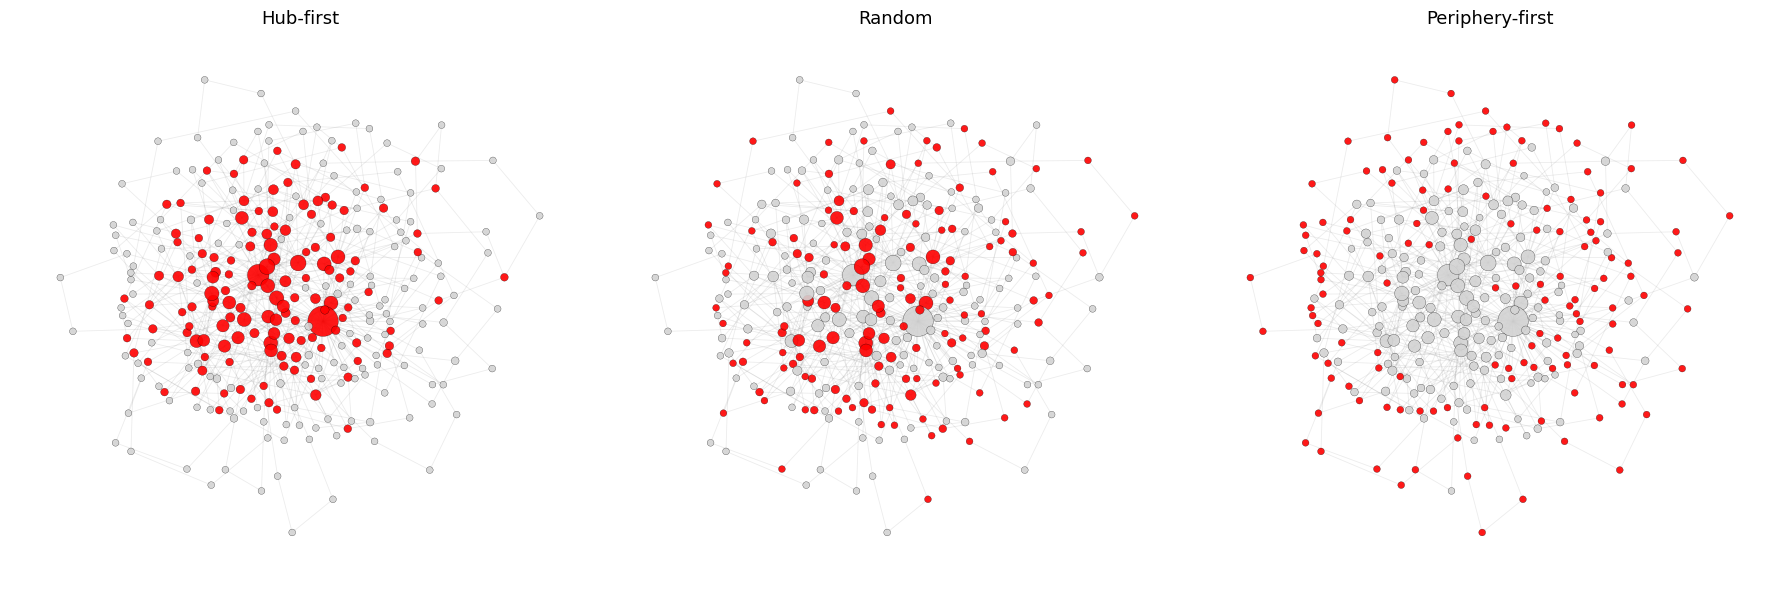

In [8]:
draw_three_ai_strategies(G, nodes, strategy_eps, layout="kamada", scale=7, figsize=(18, 6))

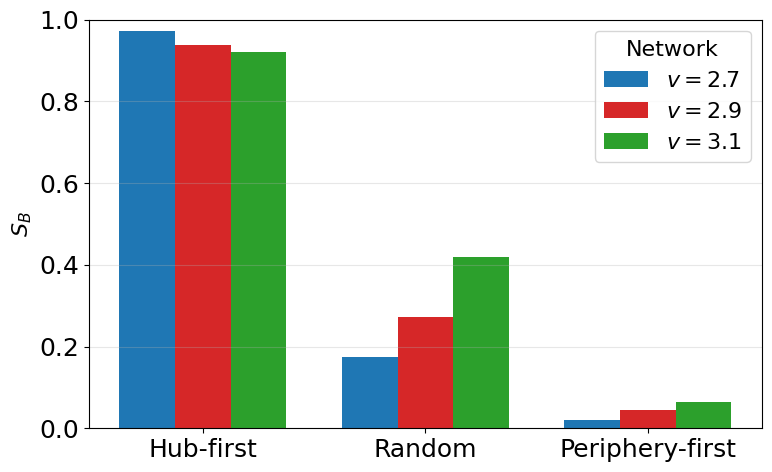

In [15]:
G1 = nx.read_edgelist("/content/drive/MyDrive/Graphs/N300_y2.7.edgelist")
G2 = nx.read_edgelist("/content/drive/MyDrive/Graphs/N300_y2.9.edgelist")
G3 = nx.read_edgelist("/content/drive/MyDrive/Graphs/N300_y3.1.edgelist")

results_networks = {
    r"$v=2.7$": compute_strategy_results_for_graph(G1, f_adopt=0.45, seed=42),
    r"$v=2.9$": compute_strategy_results_for_graph(G2, f_adopt=0.45, seed=42),
    r"$v=3.1$": compute_strategy_results_for_graph(G3, f_adopt=0.45, seed=42)}

strategies = ["Hub-first", "Random", "Periphery-first"]
colors = {
    r"$v=2.7$": "tab:blue",
    r"$v=2.9$": "tab:red",
    r"$v=3.1$": "tab:green"}
x = np.arange(len(strategies))
width = 0.25

plt.figure(figsize=(8, 5))
for j, (net_name, res_tmp) in enumerate(results_networks.items()):
    vals = [res_tmp[strategy]["S_B"] for strategy in strategies]
    plt.bar(x + (j - 1) * width, vals, width=width, color=colors[net_name], label=net_name)
#plt.axhline(1, color="k", linestyle="--", linewidth=1)

plt.xticks(x, strategies)
plt.ylabel(r"$S_B$")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Network")
plt.tight_layout()
plt.show()

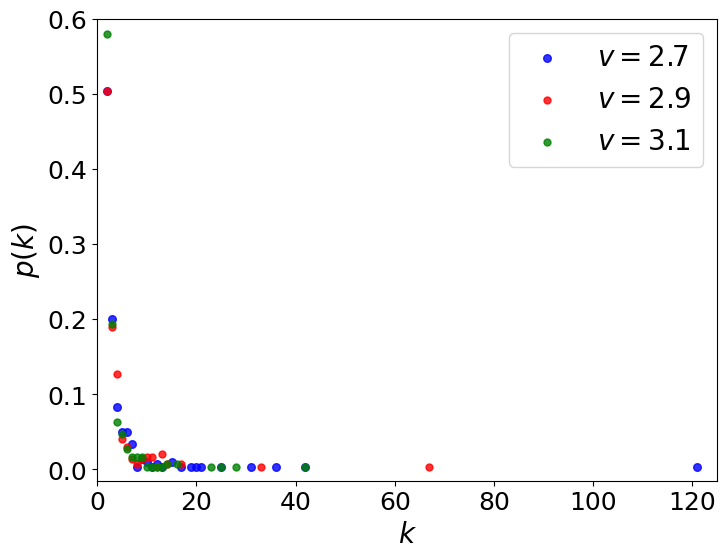

In [16]:
deg1 = [d for _, d in G1.degree()]
deg_counts1 = np.bincount(deg1)
deg_unique1 = np.arange(len(deg_counts1))
nonzero1 = deg_counts1 > 0

# Нормировка: делим на общее количество узлов
probs1 = deg_counts1 / sum(deg_counts1)

deg2 = [d for _, d in G2.degree()]
deg_counts2 = np.bincount(deg2)
deg_unique2 = np.arange(len(deg_counts2))
nonzero2 = deg_counts2 > 0

probs2 = deg_counts2 / sum(deg_counts2)

deg3 = [d for _, d in G3.degree()]
deg_counts3 = np.bincount(deg3)
deg_unique3 = np.arange(len(deg_counts3))
nonzero3 = deg_counts3 > 0

probs3 = deg_counts3 / sum(deg_counts3)

def remove_zero_y_values_np(x, y): #Убираем точки с нулевыми значениями
    x = np.array(x)
    y = np.array(y)
    mask = y != 0
    return x[mask], y[mask]

d1, pr1 = remove_zero_y_values_np(deg_unique1, probs1)
d2, pr2 = remove_zero_y_values_np(deg_unique2, probs2)
d3, pr3 = remove_zero_y_values_np(deg_unique3, probs3)

plt.figure(figsize=(8, 6))
plt.scatter(d1, pr1, s=30, color="blue", alpha=0.8, label=r"$v=2.7$")
plt.scatter(d2, pr2, s=25, color="red", alpha=0.8, label=r"$v=2.9$")
plt.scatter(d3, pr3, s=25, color="green", alpha=0.8, label=r"$v=3.1$")

#plt.xscale("log")
#plt.yscale("log")
plt.ylabel("$p(k)$", fontsize=20)
plt.xlabel("$k$", fontsize=20)
plt.xlim(0, 125)
plt.ylim(-0.015, 0.6)

plt.rc('font', weight='normal', size = 20)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)

#plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(loc='upper right', fontsize=20)
plt.show()

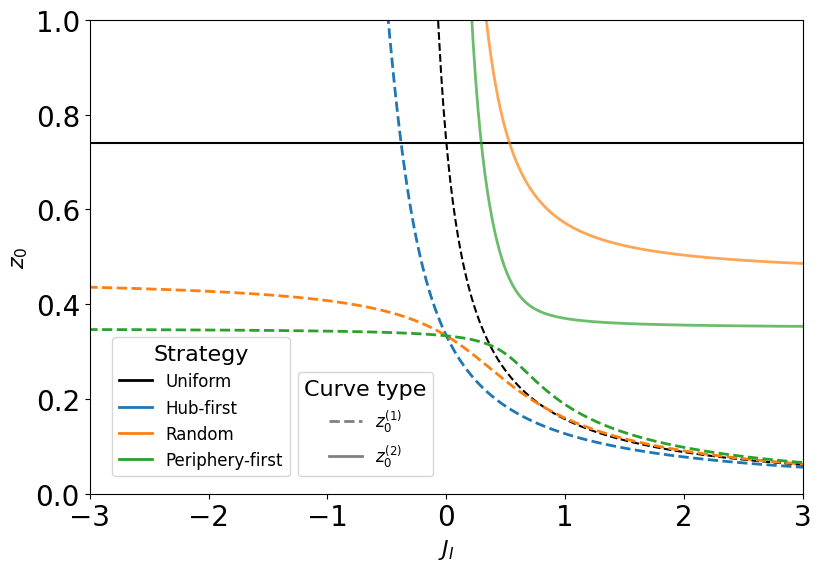

In [18]:
strategy_colors = {
    "Hub-first": "tab:blue",
    "Random": "tab:orange",
    "Periphery-first": "tab:green"}

plt.figure(figsize=(8.5, 6))

casea_bright = []
casea_dark = []

for J_I in Jpp_values:
    denom = f_adopt * Gcoop + J_I * lam1 / Gamma
    if denom > 0:
        casea_bright.append(1.0 / denom)
    else:
        casea_bright.append(np.nan)
    casea_dark.append(1.0 / (f_adopt * Gcoop))

casea_bright = np.array(casea_bright)
casea_dark = np.array(casea_dark)

plt.plot(Jpp_values, casea_bright, color="black", linestyle="--", linewidth=1.5)
plt.plot(Jpp_values, casea_dark, color="black", linestyle="-", linewidth=1.5)

for name in results.keys():
    color = strategy_colors.get(name, None)
    plt.plot(Jpp_values, results[name]["z1"], color=color, linestyle="--", linewidth=2)
    plt.plot(Jpp_values, results[name]["z2"], color=color, linestyle="-", linewidth=2, alpha=0.7)

plt.xlabel(r"$J_I$")
plt.ylabel(r"$z_0$")
#plt.title(rf"$J_R={J_R}$, $M={M}$")
plt.xlim(-3, 3)
plt.ylim(0, 1)

legend_colors = [
    Line2D([0], [0], color="black", lw=2, label="Uniform"),
    Line2D([0], [0], color="tab:blue", lw=2, label="Hub-first"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Random"),
    Line2D([0], [0], color="tab:green", lw=2, label="Periphery-first")]
leg1 = plt.legend(handles=legend_colors, loc="lower left", bbox_to_anchor=(0.02, 0.02), fontsize=12, frameon=True, title="Strategy")

legend_styles = [
    Line2D([0], [0], color="gray", lw=2, linestyle="--", label=r"$z_0^{(1)}$"),
    Line2D([0], [0], color="gray", lw=2, linestyle="-", label=r"$z_0^{(2)}$")]
leg2 = plt.legend(handles=legend_styles, loc="lower left", bbox_to_anchor=(0.28, 0.02), fontsize=12, frameon=True, title="Curve type")

plt.gca().add_artist(leg1)
plt.rc('font', weight='normal', size = 16)
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)
plt.tight_layout()
plt.show()

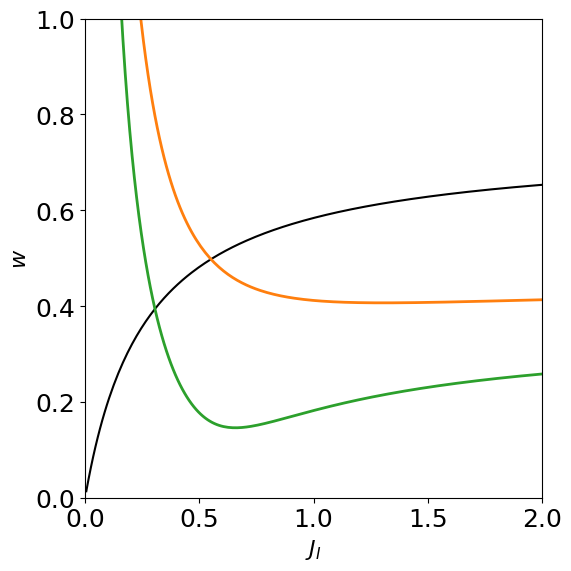

In [20]:
plt.figure(figsize=(6, 6))

casea_bright = []
casea_dark = []

for J_I in Jpp_values:
    denom = f_adopt * Gcoop + J_I * lam1 / Gamma
    if denom > 0:
        casea_bright.append(1.0 / denom)
    else:
        casea_bright.append(np.nan)
    casea_dark.append(1.0 / (f_adopt * Gcoop))
casea_bright = np.array(casea_bright)
casea_dark = np.array(casea_dark)
w_uniform = casea_dark - casea_bright
w_uniform[w_uniform < 0] = np.nan
plt.plot(Jpp_values, w_uniform, color="black", linestyle="-", linewidth=1.5, label="Uniform")

for name in results.keys():
    color = strategy_colors.get(name, None)
    z1 = results[name]["z1"]
    z2 = results[name]["z2"]
    w = z2 - z1
    w[(np.isnan(z1)) | (np.isnan(z2)) | (w < 0)] = np.nan
    plt.plot(Jpp_values, w, color=color, linestyle="-", linewidth=2, label=name)

plt.xlabel(r"$J_I$")
plt.ylabel(r"$w$")
plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.xlim(0, 2)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

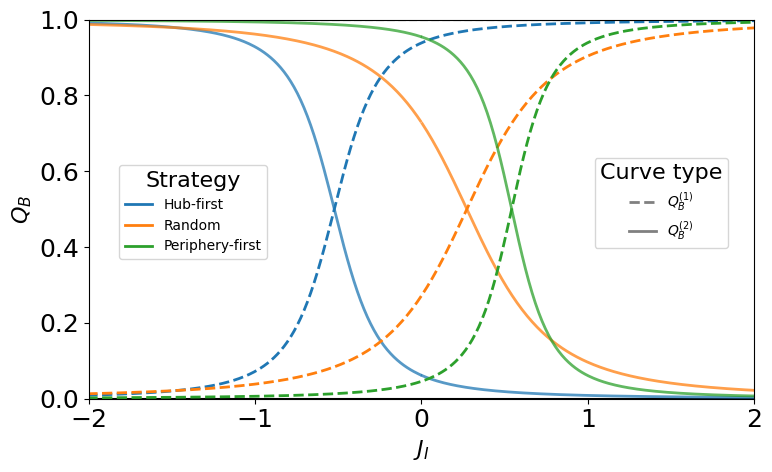

In [22]:
QB_uniform_bright = Q_B_uniform("bright")
QB_uniform_dark = Q_B_uniform("dark")

plt.figure(figsize=(8, 5))
plt.axhline(QB_uniform_bright, color="black", linestyle="--", linewidth=1.5)
plt.axhline(QB_uniform_dark, color="black", linestyle="-", linewidth=1.5)

for name in results.keys():
    color = strategy_colors.get(name, None)
    QB1 = results[name]["QB1"]
    QB2 = results[name]["QB2"]
    QBneg1 = negative_QB_results[name]["QBneg1"]
    QBneg2 = negative_QB_results[name]["QBneg2"]
    mask1 = np.isfinite(QB1)
    mask2 = np.isfinite(QB2)
    mask_neg1 = np.isfinite(QBneg1)
    mask_neg2 = np.isfinite(QBneg2)

    # Первая ветка
    if np.any(mask1):
        plt.plot(Jpp_values[mask1], QB1[mask1], color=color, linestyle="--", linewidth=2)
    # Вторая положительная ветка
    if np.any(mask2):
        plt.plot(Jpp_values[mask2], QB2[mask2], color=color, linestyle="-", linewidth=2, alpha=0.75)

    # Отрицательные математические ветки рисуем тем же стилем,
    # чтобы видеть продолжение моды
    if np.any(mask_neg1):
        plt.plot(Jpp_values[mask_neg1], QBneg1[mask_neg1], color=color, linestyle="-", linewidth=2, alpha=0.75)
    if np.any(mask_neg2):
        plt.plot(Jpp_values[mask_neg2], QBneg2[mask_neg2], color=color, linestyle="-", linewidth=2, alpha=0.75)

plt.xlabel(r"$J_I$")
plt.ylabel(r"$Q_B$")
#plt.title(rf"$J_R={J_R}$, $M={M}$")
plt.xlim(-2, 2)
plt.xticks([-2, -1, 0, 1, 2])
plt.ylim(0.0, 1.0)

legend_colors = [
    #Line2D([0], [0], color="black", lw=2, label="Uniform"),
    Line2D([0], [0], color="tab:blue", lw=2, label="Hub-first"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Random"),
    Line2D([0], [0], color="tab:green", lw=2, label="Periphery-first")]
leg1 = plt.legend(handles=legend_colors, loc="lower left", bbox_to_anchor=(0.035, 0.35), fontsize=10, frameon=True, title="Strategy")

legend_styles = [
    Line2D([0], [0], color="gray", lw=2, linestyle="--", label=r"$Q_B^{(1)}$"),
    Line2D([0], [0], color="gray", lw=2, linestyle="-", label=r"$Q_B^{(2)}$")]
leg2 = plt.legend(handles=legend_styles, loc="lower left", bbox_to_anchor=(0.75, 0.38), fontsize=10, frameon=True, title="Curve type")

plt.gca().add_artist(leg1)
plt.tight_layout()
plt.show()

In [14]:
J_I_fixed = 0.0
J_R_values = np.linspace(-5, 5, 1000)

results_JR = {}
negative_results_JR = {}
negative_QB_results_JR = {}

for name in results.keys():
    S_B = results[name]["S_B"]
    c1 = results[name]["c1"]
    d1 = results[name]["d1"]

    z1_list = []
    z2_list = []
    QB1_list = []
    QB2_list = []
    zneg1_list = []
    zneg2_list = []
    QBneg1_list = []
    QBneg2_list = []

    for J_R_current in J_R_values:
        roots = get_roots(S_B, c1, d1, J_R_current, J_I_fixed, C, M, Gamma, lam1, positive=True)
        z1, z2 = extract_two_roots(roots)
        z1_list.append(z1)
        z2_list.append(z2)
        QB1_list.append(get_Q_B(S_B, c1, d1, z1, J_R_current, J_I_fixed, C, M, Gamma, lam1))
        QB2_list.append(get_Q_B(S_B, c1, d1, z2, J_R_current, J_I_fixed, C, M, Gamma, lam1))
        neg_roots = get_roots(S_B, c1, d1, J_R_current, J_I_fixed, C, M, Gamma, lam1, positive=False)
        zneg1, zneg2 = extract_two_roots(neg_roots)
        zneg1_list.append(zneg1)
        zneg2_list.append(zneg2)
        QBneg1_list.append(get_Q_B(S_B, c1, d1, zneg1, J_R_current, J_I_fixed, C, M, Gamma, lam1))
        QBneg2_list.append(get_Q_B(S_B, c1, d1, zneg2, J_R_current, J_I_fixed, C, M, Gamma, lam1))

    results_JR[name] = {"S_B": S_B, "c1": c1, "d1": d1, "z1": np.array(z1_list), "z2": np.array(z2_list), "QB1": np.array(QB1_list), "QB2": np.array(QB2_list)}
    negative_results_JR[name] = {"zneg1": np.array(zneg1_list), "zneg2": np.array(zneg2_list)}

    negative_QB_results_JR[name] = {"QBneg1": np.array(QBneg1_list), "QBneg2": np.array(QBneg2_list)}

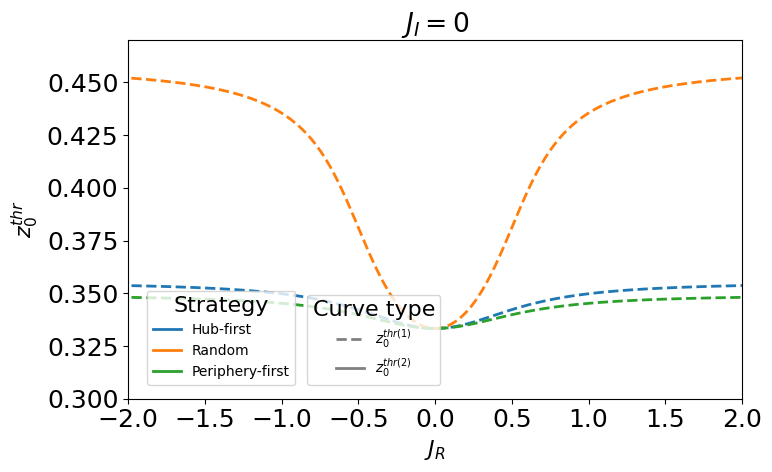

In [24]:
strategy_colors = {
    "Hub-first": "tab:blue",
    "Random": "tab:orange",
    "Periphery-first": "tab:green"}

plt.figure(figsize=(8, 5))

for name in results_JR.keys():
    color = strategy_colors.get(name, None)
    plt.plot(J_R_values, results_JR[name]["z1"], color=color, linestyle="--", linewidth=2)
    plt.plot(J_R_values, results_JR[name]["z2"], color=color, linestyle="-", linewidth=2, alpha=0.7)

plt.xlabel(r"$J_R$")
plt.ylabel(r"$z_0^{thr}$")
plt.title(r"$J_I=0$")
plt.xlim(-2, 2)
plt.ylim(0.3, 0.47)

legend_colors = [
    Line2D([0], [0], color="tab:blue", lw=2, label="Hub-first"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Random"),
    Line2D([0], [0], color="tab:green", lw=2, label="Periphery-first")]
leg1 = plt.legend(handles=legend_colors, loc="lower left", bbox_to_anchor=(0.02, 0.02), fontsize=10, frameon=True, title="Strategy")

legend_styles = [
    Line2D([0], [0], color="gray", lw=2, linestyle="--", label=r"$z_0^{thr(1)}$"),
    Line2D([0], [0], color="gray", lw=2, linestyle="-", label=r"$z_0^{thr(2)}$")]
leg2 = plt.legend(handles=legend_styles, loc="lower left", bbox_to_anchor=(0.28, 0.02), fontsize=10, frameon=True, title="Curve type")

plt.gca().add_artist(leg1)
plt.tight_layout()
plt.show()

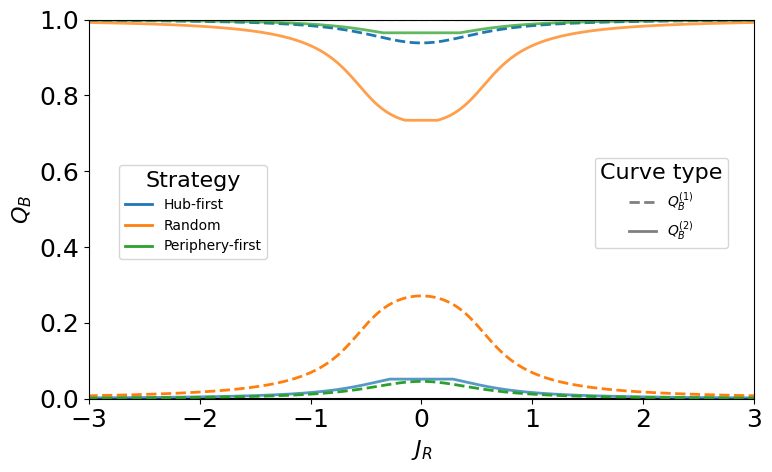

In [26]:
QB_uniform_bright = Q_B_uniform("bright")
QB_uniform_dark = Q_B_uniform("dark")

plt.figure(figsize=(8, 5))

plt.axhline(QB_uniform_bright, color="black", linestyle="--", linewidth=1.5)
plt.axhline(QB_uniform_dark, color="black", linestyle="-", linewidth=1.5)

for name in results_JR.keys():
    color = strategy_colors.get(name, None)
    QB1 = results_JR[name]["QB1"]
    QB2 = results_JR[name]["QB2"]
    QBneg1 = negative_QB_results_JR[name]["QBneg1"]
    QBneg2 = negative_QB_results_JR[name]["QBneg2"]
    mask1 = np.isfinite(QB1)
    mask2 = np.isfinite(QB2)
    mask_neg1 = np.isfinite(QBneg1)
    mask_neg2 = np.isfinite(QBneg2)

    if np.any(mask1):
        plt.plot(J_R_values[mask1], QB1[mask1], color=color, linestyle="--", linewidth=2)
    if np.any(mask2):
        plt.plot(J_R_values[mask2], QB2[mask2], color=color, linestyle="-", linewidth=2, alpha=0.75)
    if np.any(mask_neg1):
        plt.plot(J_R_values[mask_neg1],  QBneg1[mask_neg1], color=color, linestyle="-", linewidth=2, alpha=0.75)
    if np.any(mask_neg2):
        plt.plot(J_R_values[mask_neg2], QBneg2[mask_neg2], color=color, linestyle="-", linewidth=2,  alpha=0.75)

plt.xlabel(r"$J_R$")
plt.ylabel(r"$Q_B$")
#plt.title(r"$J_I=0$")

plt.xlim(-3, 3)
plt.ylim(0.0, 1.0)

legend_colors = [
    #Line2D([0], [0], color="black", lw=2, label="Uniform"),
    Line2D([0], [0], color="tab:blue", lw=2, label="Hub-first"),
    Line2D([0], [0], color="tab:orange", lw=2, label="Random"),
    Line2D([0], [0], color="tab:green", lw=2, label="Periphery-first")]
leg1 = plt.legend(handles=legend_colors, loc="lower left", bbox_to_anchor=(0.035, 0.35), fontsize=10, frameon=True, title="Strategy")

legend_styles = [
    Line2D([0], [0], color="gray", lw=2, linestyle="--", label=r"$Q_B^{(1)}$"),
    Line2D([0], [0], color="gray", lw=2, linestyle="-", label=r"$Q_B^{(2)}$")]
leg2 = plt.legend(handles=legend_styles, loc="lower left", bbox_to_anchor=(0.75, 0.38), fontsize=10, frameon=True, title="Curve type")

plt.gca().add_artist(leg1)
plt.tight_layout()
plt.show()

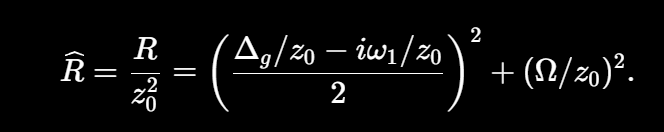

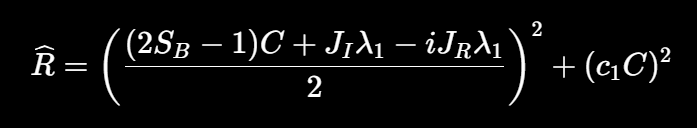

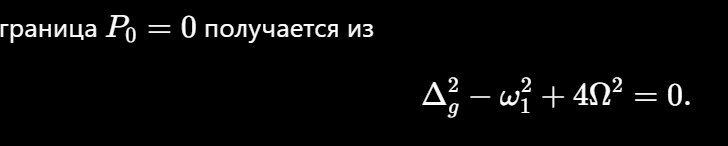

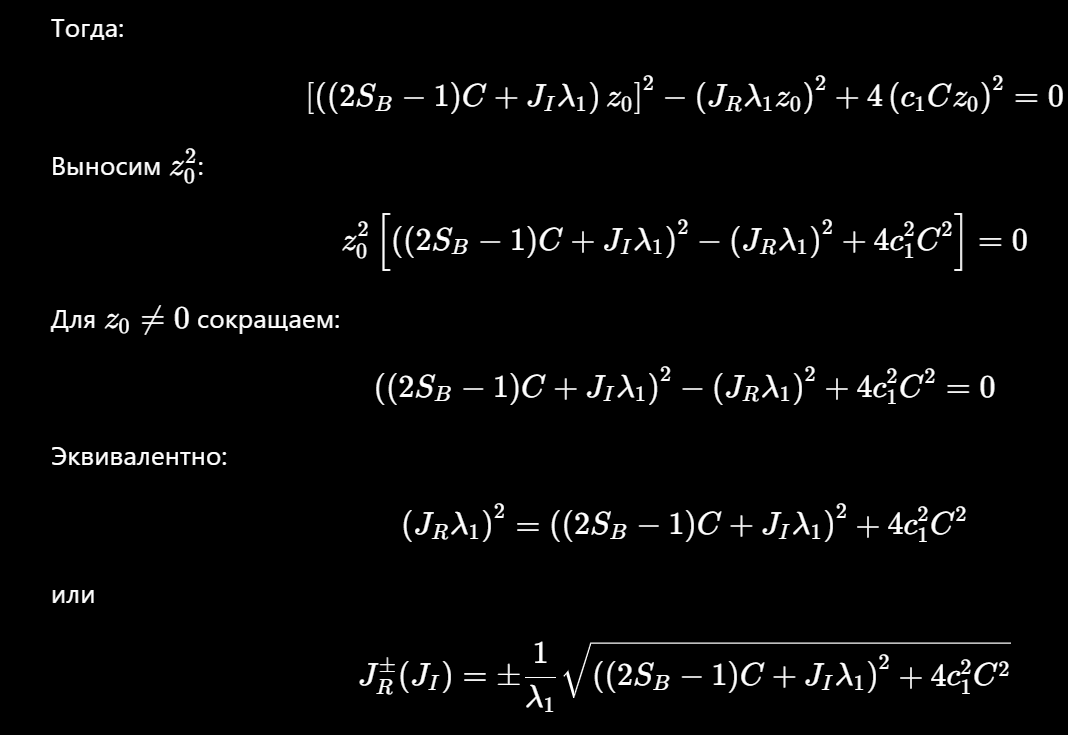

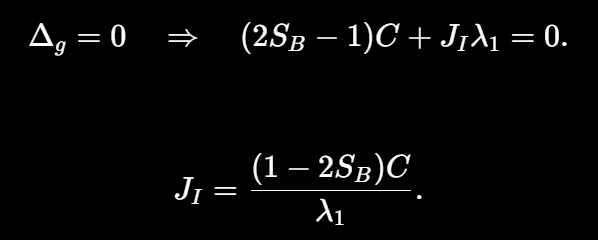

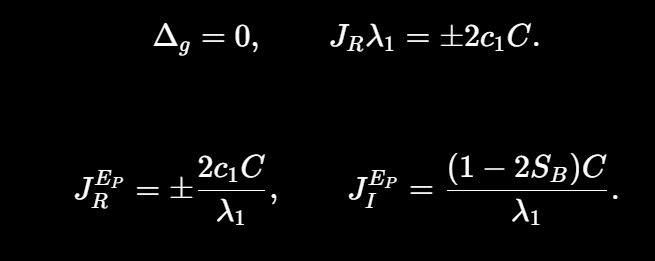

map_strategy = Periphery-first
sqrtR_mode = imag
use_splitting_factor = True
S_B = 0.04573170731707317
c1 = 0.20890265259909632
d1 = 0.9542682926829268
Gamma = 2.0
C = 6.0
lambda1 = 10.040816326530612
M_map = 0.0
row 1 of 500
row 101 of 500
row 201 of 500
row 301 of 500
row 401 of 500
finite: 250000 из 250000
min = 0.003076209548974179
max = 4.275936317411601
Delta_g=0: J_I = 0.542906008328376
E_P left:  (J_R, J_I) = (np.float64(-0.2496641457891639), np.float64(0.542906008328376))
E_P right: (J_R, J_I) = (np.float64(0.2496641457891639), np.float64(0.542906008328376))


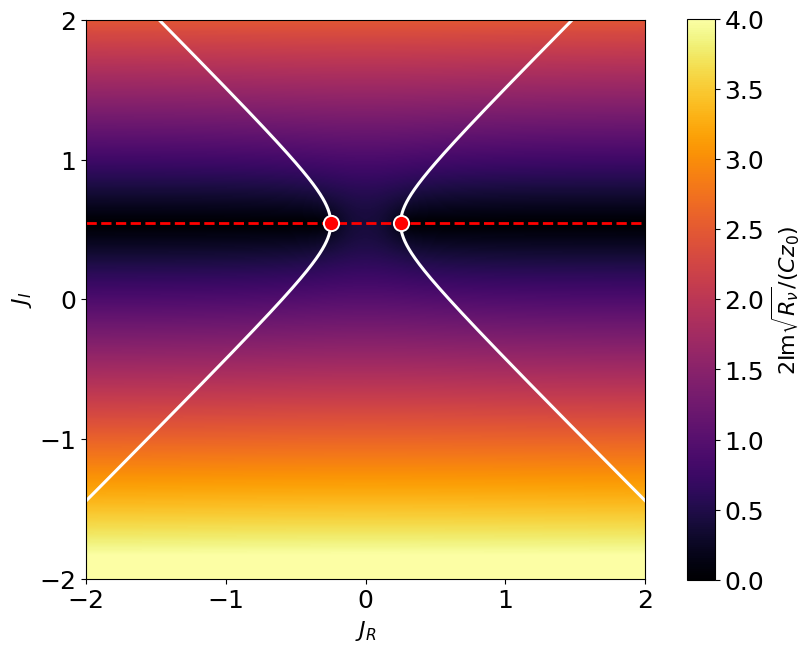

In [33]:
#sqrtR_mode = "abs"
#sqrtR_mode = "real"
sqrtR_mode = "imag"
#sqrtR_mode = "imag_abs"

use_splitting_factor = True   # True для 2 Im sqrt(R_nu)/(C z0), если sqrtR_mode="imag"
map_strategy = "Periphery-first"        # "Hub-first", "Random", "Periphery-first"
cmap_abs = "inferno"           # "viridis", "plasma", "inferno", "magma", "cividis"
cmap_signed = "coolwarm"       # "coolwarm", "seismic", "RdBu_r", "PiYG", "PRGn"

p = 4
vmax_abs_fixed = p
vmax_real_fixed = p
vmax_imag_fixed = p

S_B_map = results[map_strategy]["S_B"]
c1_map = results[map_strategy]["c1"]
d1_map = results[map_strategy]["d1"]

M_map = 0.0
m = 2.0
n_map = 500

print("map_strategy =", map_strategy)
print("sqrtR_mode =", sqrtR_mode)
print("use_splitting_factor =", use_splitting_factor)
print("S_B =", S_B_map)
print("c1 =", c1_map)
print("d1 =", d1_map)
print("Gamma =", Gamma)
print("C =", C)
print("lambda1 =", lam1)
print("M_map =", M_map)

if abs(M_map) > 1e-14:
    raise ValueError("Этот блок нормированной аналитики написан для M = 0.")

JR_values = np.linspace(-m, m, n_map)
JI_values = np.linspace(-m, m, n_map)
sqrtR_map = np.full((len(JI_values), len(JR_values)), np.nan)

def Rhat_value(S_B, c1, J_R, J_I, C, lam1):
    Delta_hat = (2.0 * S_B - 1.0) * C + J_I * lam1
    omega_hat = J_R * lam1
    Omega_hat = c1 * C
    #return ((Delta_hat - 1j * omega_hat) ** 2) / 4.0 + Omega_hat ** 2
    R_mu = ((Delta_hat - 1j * omega_hat) ** 2) / 4.0 + Omega_hat ** 2
    return R_mu

def sqrtR_normalized_value(S_B, c1, J_R, J_I, C, lam1, mode, splitting_factor=False):
    root_norm = np.sqrt(Rhat_value(S_B, c1, J_R, J_I, C, lam1)) / C      # sqrt(R_mu)/(C z0)
    root_nu = 1j * root_norm                                            # ИСПРАВЛЕНО (п.1): sqrt(R_nu)/(C z0) = i*sqrt(R_mu)/(C z0)
    if mode == "abs":
        return np.abs(root_norm)
    if mode == "real":
        return (2.0 if splitting_factor else 1.0) * np.real(root_norm)
    if mode == "imag":
        #return np.imag(root_norm)
        # БЫЛО (ОШИБКА 1): (2 if sf else 1) * np.imag(root_norm)   ->  Im[sqrt(R)]
        return (2.0 if splitting_factor else 1.0) * np.imag(root_nu)   # ИСПРАВЛЕНО (п.1): Im[i*sqrt(R)] = Im sqrt(R_nu)
    if mode == "imag_abs":
        # БЫЛО (ОШИБКА 1): np.abs(np.imag(root_norm))
        return (2.0 if splitting_factor else 1.0) * np.abs(np.imag(root_nu))   # ИСПРАВЛЕНО (п.1)
    raise ValueError("sqrtR_mode должен быть 'abs', 'real' или 'imag'")

for iy, J_I in enumerate(JI_values):
    if iy % 100 == 0:
        print("row", iy + 1, "of", len(JI_values))
    for ix, J_R in enumerate(JR_values):
        sqrtR_map[iy, ix] = sqrtR_normalized_value(S_B_map, c1_map, J_R, J_I, C, lam1, sqrtR_mode, splitting_factor=use_splitting_factor)

print("finite:", np.sum(np.isfinite(sqrtR_map)), "из", sqrtR_map.size)
print("min =", np.nanmin(sqrtR_map))
print("max =", np.nanmax(sqrtR_map))

JI_curve = np.linspace(-m, m, 2000)
JR_abs_curve = (1.0 / lam1) * np.sqrt(((2.0 * S_B_map - 1.0) * C + JI_curve * lam1) ** 2 + (2.0 * c1_map * C) ** 2)
JR_curve_left = -JR_abs_curve
JR_curve_right = JR_abs_curve

JI_delta = ((1.0 - 2.0 * S_B_map) * C) / lam1
JR_EP_left = -(2.0 * c1_map * C) / lam1
JR_EP_right = +(2.0 * c1_map * C) / lam1
JI_EP = JI_delta

print("Delta_g=0: J_I =", JI_delta)
print("E_P left:  (J_R, J_I) =", (JR_EP_left, JI_EP))
print("E_P right: (J_R, J_I) =", (JR_EP_right, JI_EP))

EP_x, EP_y = [], []
if -m <= JR_EP_left <= m and -m <= JI_EP <= m:
    EP_x.append(JR_EP_left); EP_y.append(JI_EP)
if -m <= JR_EP_right <= m and -m <= JI_EP <= m:
    EP_x.append(JR_EP_right); EP_y.append(JI_EP)

delta_visible = (-m <= JI_delta <= m)

if len(EP_x) == 0:
    print(f"ВНИМАНИЕ: точки E_P не попадают в окно [{-m},{m}] x [{-m},{m}].")
if not delta_visible:
    print(f"ВНИМАНИЕ: линия Delta_g=0 вне окна J_I in [{-m},{m}].")
finite_vals = sqrtR_map[np.isfinite(sqrtR_map)]
if finite_vals.size == 0:
    raise ValueError("Нет конечных значений sqrtR_map.")

if sqrtR_mode == "abs":
    cmap_use, vmin_use, vmax_use = cmap_abs, 0.0, vmax_abs_fixed
    title_use, cbar_label, curve_color = r"$|\sqrt{R}|/(Cz_0)$", r"$|\sqrt{R}|/(Cz_0)$", "white"
elif sqrtR_mode == "real":
    cmap_use, vmin_use, vmax_use = cmap_abs, 0.0, vmax_real_fixed
    title_use = r"$2\mathrm{Re}\sqrt{R}/(Cz_0)$" if use_splitting_factor else r"$\mathrm{Re}\sqrt{R}/(Cz_0)$"
    cbar_label, curve_color = title_use, "white"
#if sqrtR_mode == "abs":
    #cmap_use, vmin_use, vmax_use = cmap_abs, 0.0, vmax_abs_fixed
    #title_use, cbar_label, curve_color = r"$|\sqrt{R}|/(Cz_0)$", r"$|\sqrt{R}|/(Cz_0)$", "white"
#elif sqrtR_mode == "real":
    #cmap_use, vmin_use, vmax_use = cmap_abs, 0.0, vmax_real_fixed
    #title_use = r"$2\mathrm{Re}\sqrt{R}/(Cz_0)$" if use_splitting_factor else r"$\mathrm{Re}\sqrt{R}/(Cz_0)$"
    #cbar_label, curve_color = title_use, "white"
#elif sqrtR_mode == "imag":
    #cmap_use, vmin_use, vmax_use = cmap_signed, -vmax_imag_fixed, vmax_imag_fixed
    #title_use, cbar_label, curve_color = r"$\mathrm{Im}\sqrt{R}/(Cz_0)$", r"$\mathrm{Im}\sqrt{R}/(Cz_0)$", "black"
elif sqrtR_mode == "imag":
    # БЫЛО (ОШИБКА 2): cmap_use, vmin_use, vmax_use = cmap_abs, -vmax_imag_fixed, vmax_imag_fixed
    cmap_use, vmin_use, vmax_use = cmap_abs, 0.0, vmax_imag_fixed     # ИСПРАВЛЕНО (п.2): vmin = 0 (величина >= 0)
    title_use = r"$2\mathrm{Im}\sqrt{R_\nu}/(Cz_0)$" if use_splitting_factor else r"$\mathrm{Im}\sqrt{R_\nu}/(Cz_0)$"
    cbar_label, curve_color = title_use, "white"
elif sqrtR_mode == "imag_abs":
    cmap_use, vmin_use, vmax_use = cmap_abs, 0.0, vmax_imag_fixed
    title_use = r"$2|\mathrm{Im}\sqrt{R_\nu}|/(Cz_0)$" if use_splitting_factor else r"$|\mathrm{Im}\sqrt{R_\nu}|/(Cz_0)$"
    cbar_label, curve_color = title_use, "white"
if vmax_use <= vmin_use:
    vmax_use = vmin_use + 1e-12

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
im = ax.imshow(sqrtR_map, origin="lower", extent=[-m, m, -m, m], aspect="equal", cmap=cmap_use, vmin=vmin_use, vmax=vmax_use, interpolation="bilinear")
ax.plot(JR_curve_left, JI_curve, color=curve_color, linewidth=2.2, label=r"$P_0=0$")
ax.plot(JR_curve_right, JI_curve, color=curve_color, linewidth=2.2)

if delta_visible:
    ax.axhline(JI_delta, color="red", linestyle="--", linewidth=2.0, label=r"$\Delta_g=0$")
if len(EP_x) > 0:
    ax.scatter(EP_x, EP_y, color="red", edgecolor="white", s=120, linewidth=1.4, zorder=6, label=r"$E_P$")

#ax.set_title(title_use)
ax.set_xlabel(r"$J_R$")
ax.set_ylabel(r"$J_I$")
ax.set_xlim(-m, m)
ax.set_ylim(-m, m)
plt.xticks([-2, -1, 0, 1, 2])
plt.yticks([-2, -1, 0, 1, 2])
cbar = fig.colorbar(im, ax=ax, fraction=1, pad=0.06, shrink=0.7085)
cbar.set_label(cbar_label)
#ax.legend(loc="lower left", bbox_to_anchor=(-1, -1), ncol=3, frameon=True)
plt.show()

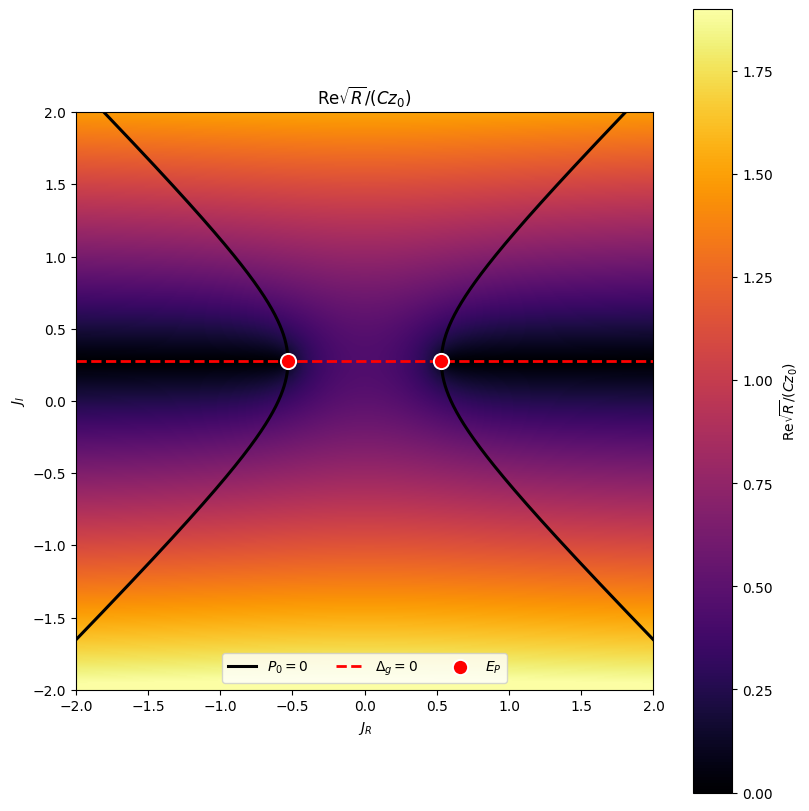

Random

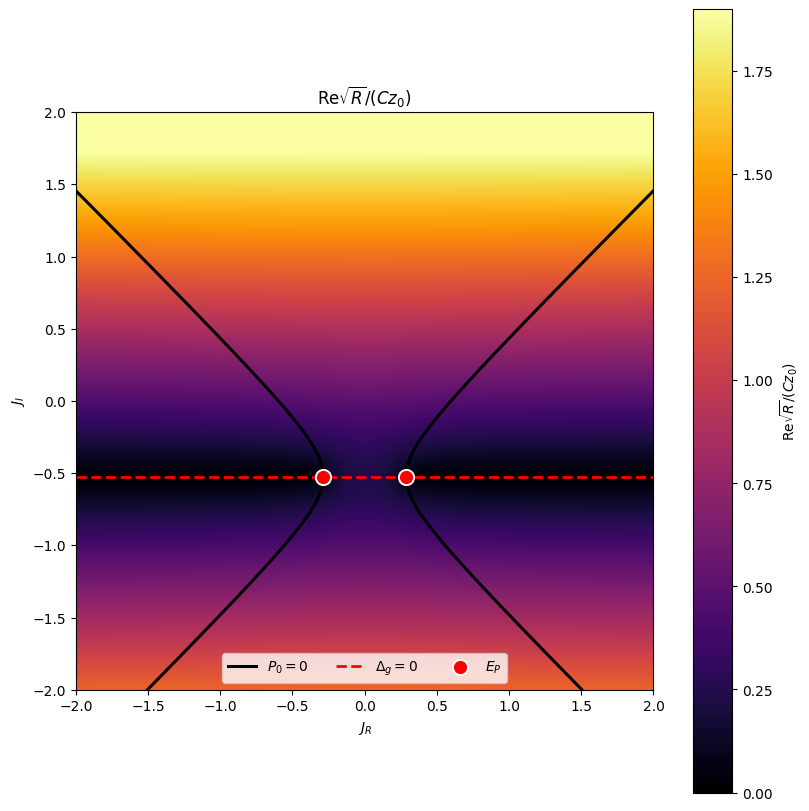

Hub-first

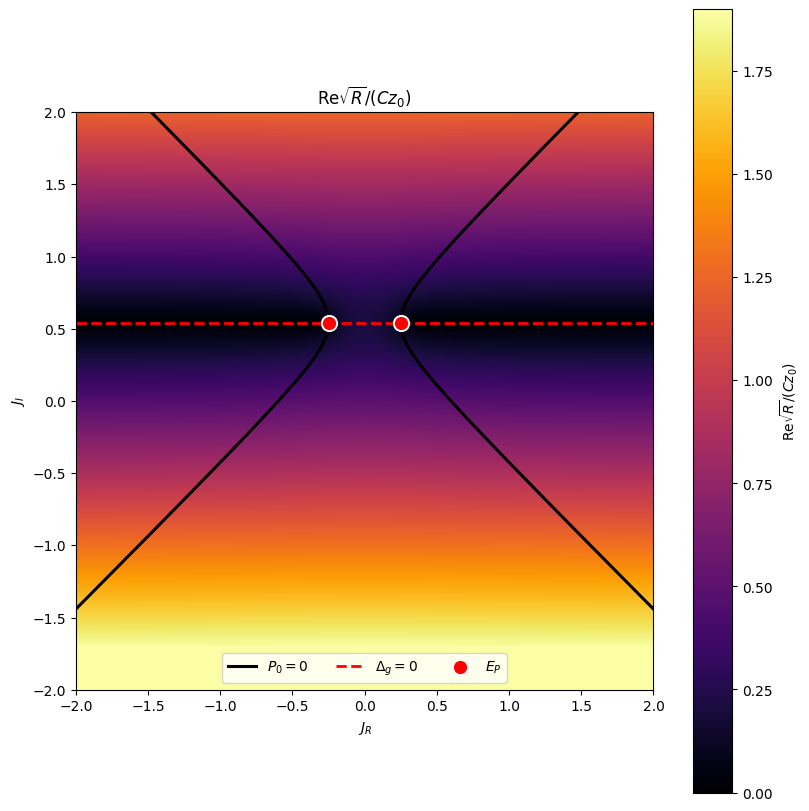

Periphery-first

map_strategy = Random
S_B = 0.27117208672086723
c1 = 0.44456471531636166
d1 = 0.7288279132791328
Gamma = 2.0
C = 6.0
lambda1 = 10.040816326530612
M_map = 0.0
row 1 of 401
row 51 of 401
row 101 of 401
row 151 of 401
row 201 of 401
row 251 of 401
row 301 of 401
row 351 of 401
row 401 of 401
W_map finite: 160801 из 160801
QB1_map finite: 160801 из 160801
QB2_map finite: 160800 из 160801
Delta_g=0: J_I = 0.2734772622116465
E_P left:  (J_R, J_I) = (np.float64(-0.5313090500122372), np.float64(0.2734772622116465))
E_P right: (J_R, J_I) = (np.float64(0.5313090500122372), np.float64(0.2734772622116465))
E_P внутри окна: [(np.float64(-0.5313090500122372), np.float64(0.2734772622116465)), (np.float64(0.5313090500122372), np.float64(0.2734772622116465))]


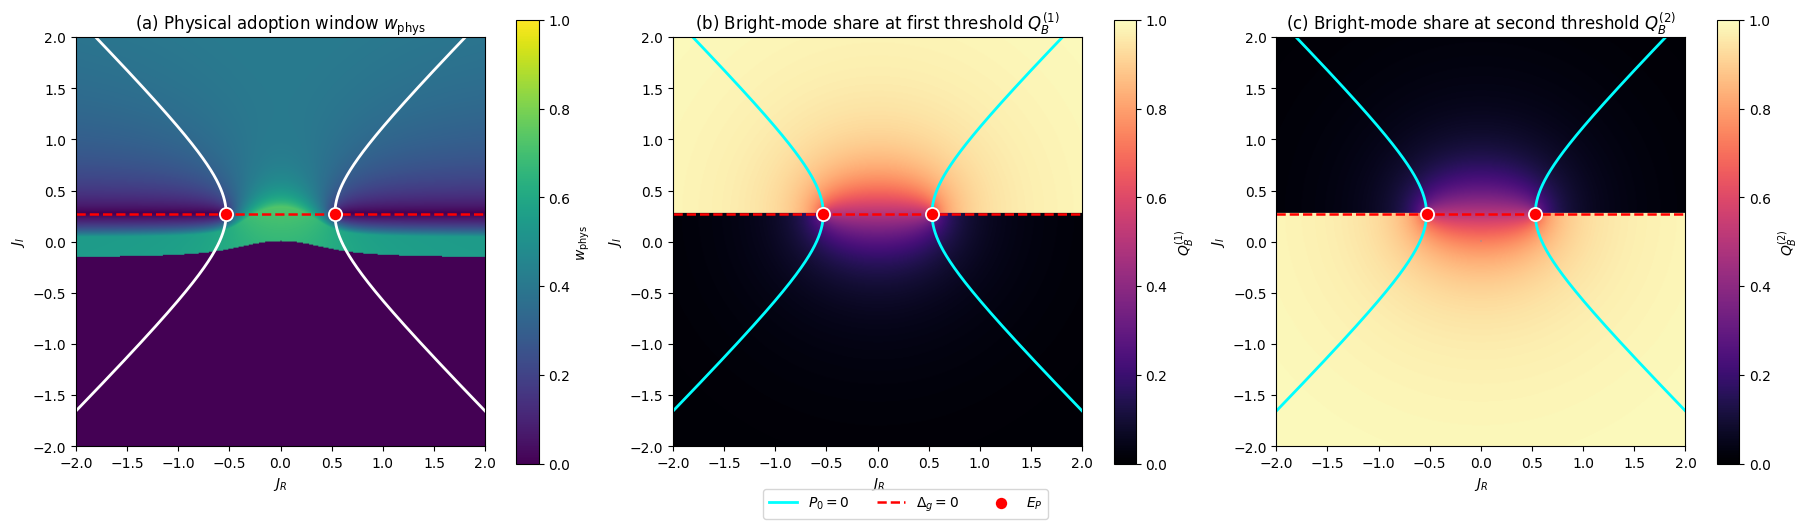

In [ ]:
# СТАРЫЙ КОД
import numpy as np
import matplotlib.pyplot as plt

map_strategy = "Random"   # можно: "Hub-first", "Random", "Periphery-first"

S_B_map = results[map_strategy]["S_B"]
c1_map = results[map_strategy]["c1"]
d1_map = results[map_strategy]["d1"]
M_map = 0.0

print("map_strategy =", map_strategy)
print("S_B =", S_B_map)
print("c1 =", c1_map)
print("d1 =", d1_map)
print("Gamma =", Gamma)
print("C =", C)
print("lambda1 =", lam1)
print("M_map =", M_map)

n_map = 401
JR_values = np.linspace(-2.0, 2.0, n_map)
JI_values = np.linspace(-2.0, 2.0, n_map)

W_map = np.full((len(JI_values), len(JR_values)), np.nan)
QB1_map = np.full((len(JI_values), len(JR_values)), np.nan)
QB2_map = np.full((len(JI_values), len(JR_values)), np.nan)

def L_tilde_coefficients_raw(S_B, c1, d1, J_R, J_I, C, lam1):
    a1 = S_B * C + J_I * lam1
    b1 = J_R * lam1
    a2 = d1 * C
    omega = c1 * C
    return a1, b1, a2, omega

def lambda_tilde_eigsystem_raw(S_B, c1, d1, J_R, J_I, C, lam1):
    a1, b1, a2, omega = L_tilde_coefficients_raw(S_B, c1, d1, J_R, J_I, C, lam1)
    Ltilde = np.array([[a1 - 1j * b1, omega], [omega, a2]], dtype=complex)
    eigvals, eigvecs = np.linalg.eig(Ltilde)
    return eigvals, eigvecs

def threshold_data_from_eigsystem(eigvals, eigvecs, Gamma):
    pos_modes = []
    neg_modes = []

    for k, lam in enumerate(eigvals):
        re_lam = np.real(lam)
        if abs(re_lam) < 1e-14:
            continue

        z0 = Gamma / re_lam
        B = eigvecs[0, k]
        D = eigvecs[1, k]
        norm2 = np.abs(B)**2 + np.abs(D)**2
        QB = np.abs(B)**2 / norm2 if norm2 > 1e-14 else np.nan
        if not np.isfinite(z0):
            continue

        mode = {"z0": z0, "QB": QB}
        if z0 > 0:
            pos_modes.append(mode)
        else:
            neg_modes.append(mode)

    pos_modes = sorted(pos_modes, key=lambda item: item["z0"])
    neg_modes = sorted(neg_modes, key=lambda item: abs(item["z0"]))
    z1_pos = pos_modes[0]["z0"] if len(pos_modes) >= 1 else np.nan
    z2_pos = pos_modes[1]["z0"] if len(pos_modes) >= 2 else np.nan
    QB1 = pos_modes[0]["QB"] if len(pos_modes) >= 1 else np.nan

    if len(pos_modes) >= 2:
        QB2 = pos_modes[1]["QB"]
    elif len(neg_modes) >= 1:
        QB2 = neg_modes[0]["QB"]
    else:
        QB2 = np.nan
    if np.isfinite(z1_pos) and np.isfinite(z2_pos) and z1_pos < 1.0:
        w_phys = max(min(z2_pos, 1.0) - z1_pos, 0.0)
    else:
        w_phys = 0.0
    return z1_pos, z2_pos, QB1, QB2, w_phys

for iy, J_I in enumerate(JI_values):
    if iy % 50 == 0:
        print("row", iy + 1, "of", len(JI_values))

    for ix, J_R in enumerate(JR_values):
        eigvals, eigvecs = lambda_tilde_eigsystem_raw(S_B_map, c1_map, d1_map, J_R, J_I, C, lam1)
        z1, z2, QB1, QB2, w_phys = threshold_data_from_eigsystem(eigvals, eigvecs, Gamma)

        W_map[iy, ix] = w_phys
        QB1_map[iy, ix] = QB1
        QB2_map[iy, ix] = QB2

print("W_map finite:", np.sum(np.isfinite(W_map)), "из", W_map.size)
print("QB1_map finite:", np.sum(np.isfinite(QB1_map)), "из", QB1_map.size)
print("QB2_map finite:", np.sum(np.isfinite(QB2_map)), "из", QB2_map.size)

JI_curve = np.linspace(-2.0, 2.0, 2000)
JR_abs_curve = (C / lam1) * np.sqrt(((2.0 * S_B_map - 1.0) + (lam1 * JI_curve / C))**2 + 4.0 * c1_map**2)

JR_curve_left = -JR_abs_curve
JR_curve_right = JR_abs_curve

JI_delta = (C / lam1) * (1.0 - 2.0 * S_B_map)
JR_EP_left = -(2.0 * C * c1_map / lam1)
JR_EP_right = +(2.0 * C * c1_map / lam1)
JI_EP = JI_delta

print("Delta_g=0: J_I =", JI_delta)
print("E_P left:  (J_R, J_I) =", (JR_EP_left, JI_EP))
print("E_P right: (J_R, J_I) =", (JR_EP_right, JI_EP))

EP_x = []
EP_y = []

if -2.0 <= JR_EP_left <= 2.0 and -2.0 <= JI_EP <= 2.0:
    EP_x.append(JR_EP_left)
    EP_y.append(JI_EP)

if -2.0 <= JR_EP_right <= 2.0 and -2.0 <= JI_EP <= 2.0:
    EP_x.append(JR_EP_right)
    EP_y.append(JI_EP)

if len(EP_x) == 0:
    print("ВНИМАНИЕ: точки E_P не попадают в окно [-2,2] x [-2,2].")
else:
    print("E_P внутри окна:", list(zip(EP_x, EP_y)))

delta_visible = (-2.0 <= JI_delta <= 2.0)

if not delta_visible:
    print("ВНИМАНИЕ: линия Delta_g=0 вне окна J_I in [-2,2].")

def add_analytic_objects(ax, hyperbola_color):
    ax.plot(JR_curve_left, JI_curve, color=hyperbola_color, linewidth=2.0, label=r"$P_0=0$")
    ax.plot(JR_curve_right, JI_curve, color=hyperbola_color, linewidth=2.0)

    if delta_visible:
        ax.axhline(JI_delta, color="red", linestyle="--", linewidth=1.8, label=r"$\Delta_g=0$")

    if len(EP_x) > 0:
        ax.scatter(EP_x, EP_y, color="red", edgecolor="white", s=90, linewidth=1.3, zorder=6, label=r"$E_P$")

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].imshow(W_map, origin="lower", extent=[-2, 2, -2, 2], aspect="equal", vmin=0.0, vmax=1.0, cmap="viridis", interpolation="bilinear")
add_analytic_objects(axes[0], hyperbola_color="white")
axes[0].set_title(r"(a) Physical adoption window $w_{\mathrm{phys}}$")
axes[0].set_xlabel(r"$J_R$")
axes[0].set_ylabel(r"$J_I$")
fig.colorbar(im0, ax=axes[0]).set_label(r"$w_{\mathrm{phys}}$")

im1 = axes[1].imshow(QB1_map, origin="lower", extent=[-2, 2, -2, 2], aspect="equal", vmin=0.0, vmax=1.0, cmap="magma", interpolation="bilinear")
add_analytic_objects(axes[1], hyperbola_color="cyan")
axes[1].set_title(r"(b) Bright-mode share at first threshold $Q_B^{(1)}$")
axes[1].set_xlabel(r"$J_R$")
axes[1].set_ylabel(r"$J_I$")
fig.colorbar(im1, ax=axes[1]).set_label(r"$Q_B^{(1)}$")

im2 = axes[2].imshow(QB2_map, origin="lower", extent=[-2, 2, -2, 2], aspect="equal", vmin=0.0, vmax=1.0, cmap="magma", interpolation="bilinear")
add_analytic_objects(axes[2], hyperbola_color="cyan")
axes[2].set_title(r"(c) Bright-mode share at second threshold $Q_B^{(2)}$")
axes[2].set_xlabel(r"$J_R$")
axes[2].set_ylabel(r"$J_I$")
fig.colorbar(im2, ax=axes[2]).set_label(r"$Q_B^{(2)}$")
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, -0.05))
plt.show()

map_strategy = Hub-first
S_B = 0.9381775067750677
c1 = 0.2408328726656423
d1 = 0.06182249322493227
Gamma = 2.0
C = 6.0
lambda1 = 10.040816326530612
M_map = 0.0
row 1 of 401
row 51 of 401
row 101 of 401
row 151 of 401
row 201 of 401
row 251 of 401
row 301 of 401
row 351 of 401
row 401 of 401
W_map finite: 160801 из 160801
H_map finite: 160801 из 160801
W min/max: 0.0 0.922459077843409
H min/max: 0.01268859056748095 0.9553285195753254
Delta_g=0: J_I = -0.52367555687752
E_P left:  (J_R, J_I) = (np.float64(-0.28782465269796276), np.float64(-0.52367555687752))
E_P right: (J_R, J_I) = (np.float64(0.28782465269796276), np.float64(-0.52367555687752))
E_P внутри окна: [(np.float64(-0.28782465269796276), np.float64(-0.52367555687752)), (np.float64(0.28782465269796276), np.float64(-0.52367555687752))]


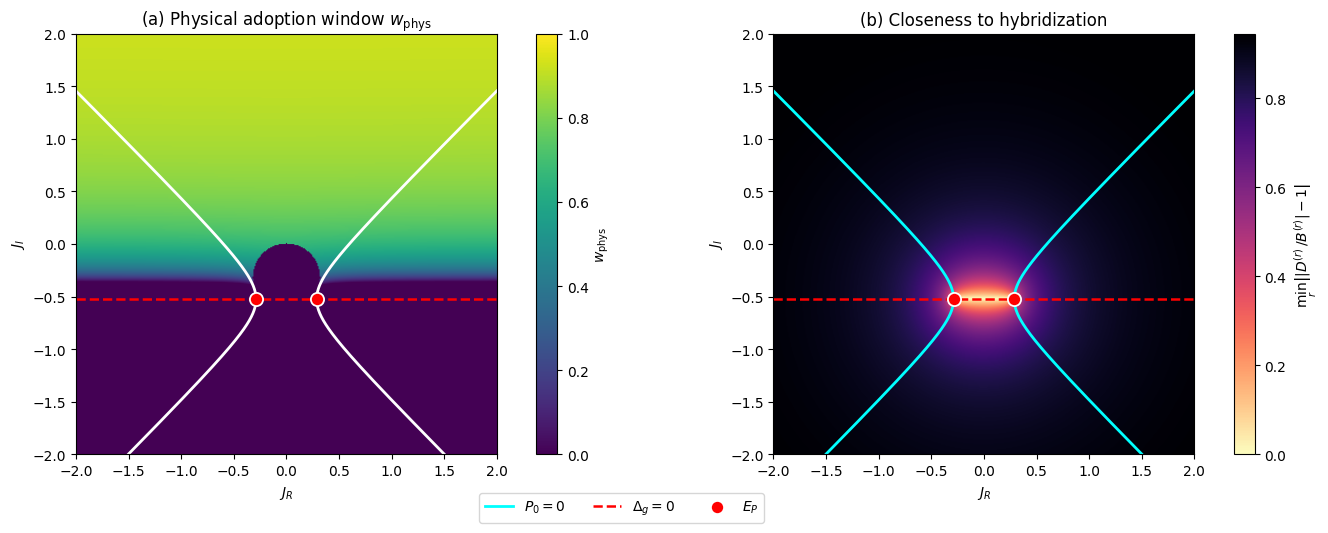

In [ ]:
# СТАРЫЙ КОД
import numpy as np
import matplotlib.pyplot as plt

map_strategy = "Hub-first"  # "Hub-first", "Random", "Periphery-first"

S_B_map = results[map_strategy]["S_B"]
c1_map = results[map_strategy]["c1"]
d1_map = results[map_strategy]["d1"]
M_map = 0.0

print("map_strategy =", map_strategy)
print("S_B =", S_B_map)
print("c1 =", c1_map)
print("d1 =", d1_map)
print("Gamma =", Gamma)
print("C =", C)
print("lambda1 =", lam1)
print("M_map =", M_map)

n_map = 401
JR_values = np.linspace(-2.0, 2.0, n_map)
JI_values = np.linspace(-2.0, 2.0, n_map)

W_map = np.full((len(JI_values), len(JR_values)), np.nan)
H_map = np.full((len(JI_values), len(JR_values)), np.nan)

def L_tilde_coefficients_raw(S_B, c1, d1, J_R, J_I, C, lam1):
    a1 = S_B * C + J_I * lam1
    b1 = J_R * lam1
    a2 = d1 * C
    omega = c1 * C
    return a1, b1, a2, omega

def lambda_tilde_eigs_raw(S_B, c1, d1, J_R, J_I, C, lam1):
    a1, b1, a2, omega = L_tilde_coefficients_raw(S_B, c1, d1, J_R, J_I, C, lam1)
    Ltilde = np.array([[a1 - 1j * b1, omega], [omega, a2]], dtype=complex)
    eigvals = np.linalg.eigvals(Ltilde)
    return eigvals, a1, b1, omega

def physical_window_from_lambdas(eigvals, Gamma):
    z_values = []
    for lam in eigvals:
        re_lam = np.real(lam)
        if re_lam > 1e-14:
            z0 = Gamma / re_lam
            if np.isfinite(z0):
                z_values.append(z0)
    if len(z_values) < 2:
        return 0.0
    z1, z2 = sorted(z_values)[:2]
    if z1 >= 1.0:
        return 0.0
    return max(min(z2, 1.0) - z1, 0.0)

def hybridization_from_lambdas(eigvals, a1, b1, omega):
    if abs(omega) < 1e-14:
        return np.nan
    vals = []
    for lam in eigvals:
        ratio = abs((lam - (a1 - 1j * b1)) / omega)
        if np.isfinite(ratio):
            vals.append(abs(ratio - 1.0))
    return min(vals) if len(vals) > 0 else np.nan

for iy, J_I in enumerate(JI_values):
    if iy % 50 == 0:
        print("row", iy + 1, "of", len(JI_values))
    for ix, J_R in enumerate(JR_values):
        eigvals, a1, b1, omega = lambda_tilde_eigs_raw(S_B_map, c1_map, d1_map, J_R, J_I, C, lam1)
        W_map[iy, ix] = physical_window_from_lambdas(eigvals, Gamma)
        H_map[iy, ix] = hybridization_from_lambdas(eigvals, a1, b1, omega)

print("W_map finite:", np.sum(np.isfinite(W_map)), "из", W_map.size)
print("H_map finite:", np.sum(np.isfinite(H_map)), "из", H_map.size)
print("W min/max:", np.nanmin(W_map), np.nanmax(W_map))
print("H min/max:", np.nanmin(H_map), np.nanmax(H_map))

# Аналитические линии: P0=0, Delta_g=0, E_P
JI_curve = np.linspace(-2.0, 2.0, 2000)
JR_abs_curve = (C / lam1) * np.sqrt(((2.0 * S_B_map - 1.0) + (lam1 * JI_curve / C))**2 + 4.0 * c1_map**2)
JR_curve_left = -JR_abs_curve
JR_curve_right = JR_abs_curve

JI_delta = (C / lam1) * (1.0 - 2.0 * S_B_map)
JR_EP_left = -(2.0 * C * c1_map / lam1)
JR_EP_right = +(2.0 * C * c1_map / lam1)
JI_EP = JI_delta

print("Delta_g=0: J_I =", JI_delta)
print("E_P left:  (J_R, J_I) =", (JR_EP_left, JI_EP))
print("E_P right: (J_R, J_I) =", (JR_EP_right, JI_EP))

EP_x, EP_y = [], []
if -2.0 <= JR_EP_left <= 2.0 and -2.0 <= JI_EP <= 2.0:
    EP_x.append(JR_EP_left); EP_y.append(JI_EP)
if -2.0 <= JR_EP_right <= 2.0 and -2.0 <= JI_EP <= 2.0:
    EP_x.append(JR_EP_right); EP_y.append(JI_EP)

delta_visible = (-2.0 <= JI_delta <= 2.0)
if len(EP_x) == 0:
    print("ВНИМАНИЕ: точки E_P не попадают в окно [-2,2] x [-2,2].")
else:
    print("E_P внутри окна:", list(zip(EP_x, EP_y)))
if not delta_visible:
    print("ВНИМАНИЕ: линия Delta_g=0 вне окна J_I in [-2,2].")

H_plot = H_map.copy()
H_vmax = np.nanpercentile(H_plot[np.isfinite(H_plot)], 95) if np.any(np.isfinite(H_plot)) else 0.8
if H_vmax <= 1e-14:
    H_vmax = 0.8
H_plot = np.clip(H_plot, 0.0, H_vmax)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

def add_analytic_objects(ax, hyperbola_color):
    ax.plot(JR_curve_left, JI_curve, color=hyperbola_color, linewidth=2.0, label=r"$P_0=0$")
    ax.plot(JR_curve_right, JI_curve, color=hyperbola_color, linewidth=2.0)
    if delta_visible:
        ax.axhline(JI_delta, color="red", linestyle="--", linewidth=1.8, label=r"$\Delta_g=0$")
    if len(EP_x) > 0:
        ax.scatter(EP_x, EP_y, color="red", edgecolor="white", s=90, linewidth=1.3, zorder=6, label=r"$E_P$")
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

im0 = axes[0].imshow(W_map, origin="lower", extent=[-2, 2, -2, 2], aspect="equal", vmin=0.0, vmax=1.0, cmap="viridis", interpolation="bilinear")
add_analytic_objects(axes[0], hyperbola_color="white")
axes[0].set_title(r"(a) Physical adoption window $w_{\mathrm{phys}}$")
axes[0].set_xlabel(r"$J_R$")
axes[0].set_ylabel(r"$J_I$")
fig.colorbar(im0, ax=axes[0]).set_label(r"$w_{\mathrm{phys}}$")

im1 = axes[1].imshow(H_plot, origin="lower", extent=[-2, 2, -2, 2], aspect="equal", vmin=0.0, vmax=H_vmax, cmap="magma_r", interpolation="bilinear")
add_analytic_objects(axes[1], hyperbola_color="cyan")
axes[1].set_title(r"(b) Closeness to hybridization")
axes[1].set_xlabel(r"$J_R$")
axes[1].set_ylabel(r"$J_I$")
fig.colorbar(im1, ax=axes[1]).set_label(r"$\min_r \left||D^{(r)}/B^{(r)}|-1\right|$")
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, -0.05))
plt.show()